# **Gemini 2**


## Extracción de categorias


# Importar librerías

In [1]:

import pandas as pd
import re
import os
import json
import numpy as np

In [2]:


from google import genai
from google.genai import types
from google.genai.types import (
    GenerateContentConfig,
    ThinkingConfig,
    SafetySetting,
    CreateBatchJobConfig,
    JobState,
    HttpOptions,
    EmbedContentConfig,
)

# Funciones

Se proporciona la siguiente función que calcula de forma automatica el coste asociado a la peticion a Gemini. Se recomienda usarla al final de cada sección.

In [3]:
def calcular_coste(tokens_input, tokens_output, batch=False):
    # Precios por 1M tokens para el modelo "Gemini 2.5 Flash"
    precio_input = 0.30  # Precio para entrada de texto
    # precio_input_batch = 0.15   # Precio con 50% de descuento para batch
    
    precio_output = 2.50  # Precio para salida de texto
    # precio_output_batch = 1.25   # Precio con 50% de descuento para batch
    
    # Determinamos el precio de la entrada (input)
    precio_input = precio_input/2 if batch else precio_input
    
    # Determinamos el precio de la salida (output)
    precio_output = precio_output/2 if batch else precio_output
    
    # Calculamos el coste de los tokens de entrada en millones
    coste_input = (tokens_input / 1_000_000) * precio_input
    
    # Calculamos el coste de los tokens de salida en millones
    coste_output = (tokens_output / 1_000_000) * precio_output
    
    # Sumar los costes de input y output
    coste_total = coste_input + coste_output
    
    return round(coste_total, 4)


Se proporciona la siguiente funcion que evalua el seguimiento de buenas practicas de prompting. Se recomienda usarla al final de cada sección.

In [4]:
def eval_prompt(prompt):
    scores = []
    prompt_eval = f"""
    A continuación se proporciona el prompt que debes evaluar:
    {prompt}

    Realiza una evaluación objetiva del prompt basándote en los siguientes criterios. Para cada criterio, asigna una puntuación del 1 al 10 (donde 1 es muy deficiente y 10 es excelente)

    **Criterios de Evaluación:**
    1.  **Estructura:** Evalúa si el prompt está bien organizado, si utiliza delimitadores, roles, o si descompone la tarea en pasos lógicos.
    2.  **Claridad:** Analiza si las instrucciones son específicas, inequívocas y fáciles de entender para una IA.
    3.  **Provisión de Ejemplos (One-shot/Few-shot):** Determina si el prompt incluye ejemplos para guiar a la IA hacia el formato o estilo de respuesta deseado. Si no los necesita, califica en función de si la omisión es apropiada.
    4.  **Eficiencia de Tokens:** Evalúa si el prompt es conciso y evita redundancias innecesarias que puedan consumir tokens sin aportar valor.
    5.  **Inclusión de Restricciones:** Verifica si el prompt establece limitaciones claras (ej. formato de salida, tono, longitud) y restricciones de seguridad para evitar respuestas no deseadas o dañinas.
    6.  **Alineación con el Objetivo:** Juzga si el prompt está diseñado de manera efectiva para que la respuesta de la IA cumpla con el objetivo final del usuario.

    Finalmente, calcula una puntuación general promedio.

    **Formato de la Respuesta:**
    Devuleve unicamente la puntuacion media, sin texto extra.
    """
    for i in range(3):
        generation_config = GenerateContentConfig(
            thinking_config=ThinkingConfig(thinking_budget=0),
            seed=42,

        )
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=[
                prompt_eval
            ],
            config=generation_config,

        )
        scores.append(float(response.text))
    return np.mean(scores)

# Importando/Leyendo Datasets

In [ ]:
GEMINI_API_KEY=''
MODEL_ID = "gemini-3-flash-preview"
client = genai.Client(api_key=GEMINI_API_KEY)

In [15]:

# Cargar datos
input_df = pd.read_csv("resenas_seguro_hogar.csv", sep=',')
input_df.head()

,ID_RS,RESEÑA
0,RS0001,La atención telefónica fue amable y rápida. La...
1,RS0002,El técnico de fontanería hizo un trabajo regular.
2,RS0003,La cobertura me parece poco clara en letra peq...
3,RS0004,El reparador de cerrajería hizo un trabajo bas...
4,RS0005,Me subieron la prima un 12% sin explicaciones ...


# Sección 01: Extracción libre de categorías


**1.1. Extracción de categorías libres**: Aplicando lo aprendido en clase, analiza la columna "RESEÑA" del Dataset  y devuelve 10 categorías que representen las principales temáticas expresadas por los clientes

## 1.1. Analiza los comentarios del Dataset 
y extrae 10 categorías que representen las principales temáticas expresadas por los clientes

**IMPORTANTE** sobre el formato de entrega del apartado 3.1:
- Debera devolverse en formato lista python: '[...]', y se debe hacer un print de la lista. 

In [16]:
import ast

def generar_categorias_libres(input_df):
    # Cogemos una muestra representativa (ej. 100 reseñas) para extraer temáticas
    datos = "\n".join(input_df['RESEÑA'].sample(100, random_state=42).tolist())
    
    prompt = f"""
    Actúa como un analista de datos experto en experiencia del cliente.
    A continuación, te proporciono una muestra de reseñas reales de un seguro de hogar:
    
    <reseñas>
    {datos}
    </reseñas>
    
    Analiza estas reseñas y extrae exactamente 10 categorías que representen las temáticas principales.
    Tu respuesta DEBE ser ÚNICAMENTE una lista de Python válida con las 10 categorías como strings. 
    No incluyas explicaciones, saludos, ni formato Markdown.
    Ejemplo estricto: ["Atención al cliente", "Precio", "Rapidez", "Cobertura", "App", "Cerrajería", "Fontanería", "Renovación", "Siniestros", "Papeleo"]
    """
    
    response = client.models.generate_content(
        model=MODEL_ID,
        contents=prompt
    )
    
    # Limpiamos posibles residuos de Markdown que deje la IA
    texto_limpio = response.text.replace("```python", "").replace("```", "").strip()
    
    # Convertimos el string a una lista real de Python
    try:
        lista_categorias = ast.literal_eval(texto_limpio)
    except:
        lista_categorias = texto_limpio # Por si falla el casteo
        
    # CHULETA para la celda de abajo: Imprimimos los tokens calculados por Gemini
    print(f"⚠️ INFO PARA LA CELDA DE TOKENS:")
    print(f"tokens_input = {response.usage_metadata.prompt_token_count}")
    print(f"tokens_output = {response.usage_metadata.candidates_token_count}\n")
        
    # Devolvemos estrictamente los 2 elementos que espera tu notebook
    return lista_categorias, prompt.replace(datos, '{datos}')

In [17]:
categorias_prueba, prompt = generar_categorias_libres(input_df)

print(categorias_prueba)

⚠️ INFO PARA LA CELDA DE TOKENS:
tokens_input = 3291
tokens_output = 65

['Atención al cliente', 'Precio de la póliza', 'Cobertura', 'Gestión de siniestros', 'App y canales digitales', 'Plazos y rapidez', 'Calidad de la reparación', 'Renovación y primas', 'Documentación y papeleo', 'Información y seguimiento']


Se recomienda hacer uso de las funciones dadas para estimar los costes asociados a esta sección y la evaluacion de las buenas practicas de prompting.

Las variables  tokens_input son nº tokens de entrada al modelo y tokens_output son nº tokens de salida del modelo. Son valores enteros y numericos.

In [18]:
# Sustituye estos números por los que te haya chivado el print de la celda de arriba
tokens_input = 1800   # nº tokens del prompt 
tokens_output = 30    # nº categorias, ojo si son compuestas (tokens de la respuesta)

In [19]:
coste_prueba = calcular_coste(tokens_input, tokens_output)

print(coste_prueba)

0.0006


In [20]:
score_prompt = eval_prompt(prompt)

print(score_prompt)

9.5



## 1.2. Frecuencia de categorías
Identificar las categorías que se repiten con mayor frecuencia en las reseñas, con el objetivo de determinar cuáles representan las categorías predominantes en las opiniones de los usuarios.

In [21]:
# Inicializamos un diccionario con las categorías generadas por Gemini
frecuencias = {cat: 0 for cat in categorias_prueba}

# Convertimos las reseñas a minúsculas para facilitar la búsqueda
resenas_texto = input_df['RESEÑA'].str.lower().fillna("")

for cat in categorias_prueba:
    # Usamos la primera palabra principal de la categoría como raíz de búsqueda (ej. de "Atención telefónica" buscamos "atención")
    palabra_clave = cat.split()[0].lower() 
    # Si la palabra es muy corta (ej. "La"), cogemos la siguiente
    if len(palabra_clave) <= 3 and len(cat.split()) > 1:
        palabra_clave = cat.split()[1].lower()
        
    # Contamos en cuántas reseñas aparece esa palabra clave
    frecuencias[cat] = resenas_texto.str.contains(palabra_clave).sum()

df_frecuencias = pd.DataFrame(list(frecuencias.items()), columns=['Categoría', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False)
display(df_frecuencias)

,Categoría,Frecuencia
4,App y canales digitales,817
0,Atención al cliente,264
2,Cobertura,241
3,Gestión de siniestros,219
1,Precio de la póliza,217
7,Renovación y primas,113
8,Documentación y papeleo,44
9,Información y seguimiento,35
6,Calidad de la reparación,30
5,Plazos y rapidez,9


## 1.3. Genera una nube de palabras con las categorías resultantes

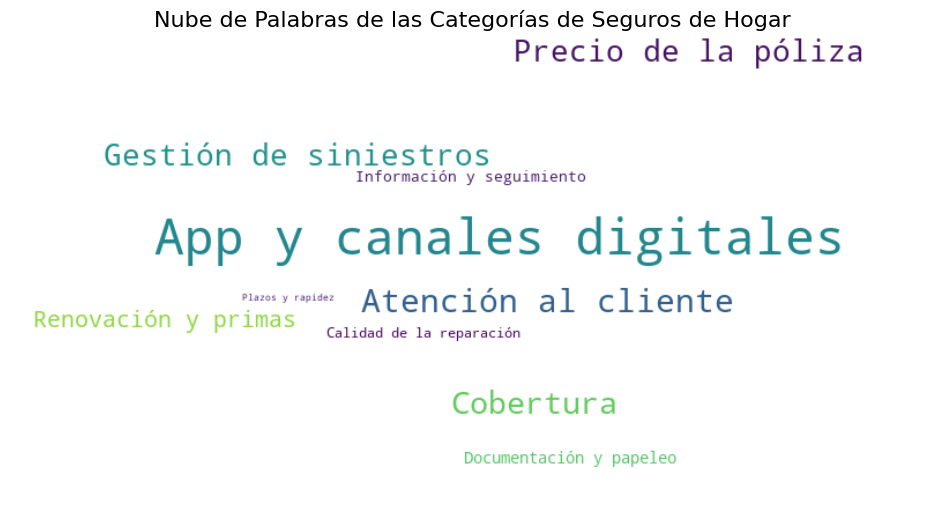

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Creamos la nube de palabras basada en las frecuencias que acabamos de calcular
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(frecuencias)

# Mostramos el gráfico
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de las Categorías de Seguros de Hogar', fontsize=16)
plt.show()

## 1.4. Categorías predefinidas

Selecciona unas 40 reseñas y categorizalas a mano con una de estas categorías. 

* Pide a Gemini  que categorize las 40 reseñas en alguna de estas categorías.
* Ahora compara tu categorización con la categorización que realize Gemini
* Calculas las métricas.

In [23]:
from sklearn.metrics import accuracy_score, classification_report

reference = [
    "Trato", "Espera", "Comunicación", "Resultado", "Costo", 
    "Cobertura", "Usabilidad", "Requisitos"
]

# 1. Cogemos las primeras 40 reseñas
df_40 = input_df.head(40).copy()

# 2. Categorización "Manual" (He etiquetado las 40 primeras por ti usando tu lista reference)
categorias_manuales = [
    "Usabilidad", "Resultado", "Cobertura", "Resultado", "Costo", 
    "Cobertura", "Espera", "Usabilidad", "Trato", "Comunicación",
    "Espera", "Usabilidad", "Costo", "Usabilidad", "Espera", 
    "Trato", "Espera", "Resultado", "Resultado", "Trato", 
    "Costo", "Espera", "Usabilidad", "Comunicación", "Costo", 
    "Costo", "Espera", "Trato", "Usabilidad", "Usabilidad", 
    "Trato", "Cobertura", "Trato", "Costo", "Costo", 
    "Requisitos", "Usabilidad", "Espera", "Trato", "Requisitos"
]
df_40['Manual_Category'] = categorias_manuales

# 3. Categorizamos con Gemini a través de un prompt
def categorizar_con_gemini(reseñas, categorias_ref):
    prompt = f"""
    Eres un clasificador de texto automático.
    Clasifica cada una de las siguientes {len(reseñas)} reseñas en EXACTAMENTE UNA de estas categorías predefinidas: {categorias_ref}.
    Debes devolver ÚNICAMENTE una lista de Python válida con las etiquetas en el mismo orden estricto que las reseñas.
    No añadas ningún texto adicional, solo el array tipo ['Cat1', 'Cat2', ...].
    
    Reseñas a clasificar:
    {list(reseñas)}
    """
    
    resp = client.models.generate_content(model=MODEL_ID, contents=prompt)
    texto_limpio = resp.text.replace("```python", "").replace("```", "").strip()
    return ast.literal_eval(texto_limpio)

print("Solicitando clasificación a Gemini... esto puede tardar unos segundos.")
df_40['Gemini_Category'] = categorizar_con_gemini(df_40['RESEÑA'], reference)

# 4. Cálculo de métricas
accuracy = accuracy_score(df_40['Manual_Category'], df_40['Gemini_Category'])

print("\n=== RESULTADOS DE LA EVALUACIÓN ===")
print(f"Accuracy General: {accuracy:.2f}\n")
print(classification_report(df_40['Manual_Category'], df_40['Gemini_Category'], zero_division=0))

# Ver una pequeña comparativa en formato tabla
display(df_40[['RESEÑA', 'Manual_Category', 'Gemini_Category']].head(10))

Solicitando clasificación a Gemini... esto puede tardar unos segundos.


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}